In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

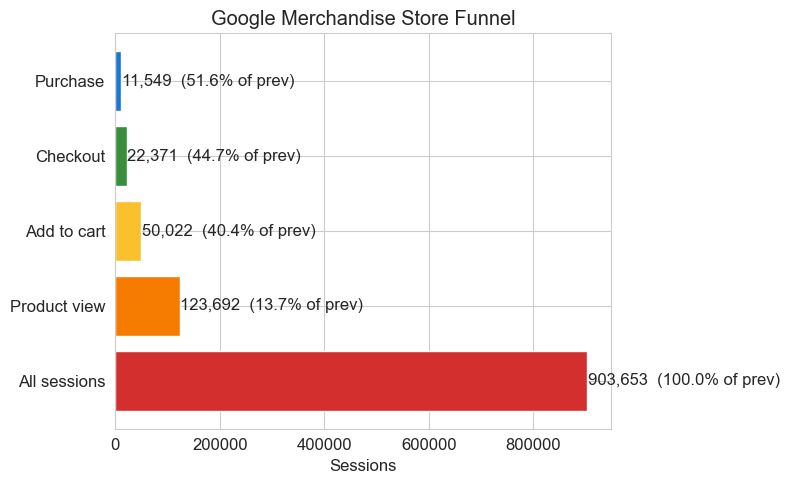

In [5]:
# 1. Funnel chart
funnel_data = {
    "step": ["All sessions", "Product view", "Add to cart", "Checkout", "Purchase"],
    "sessions": [903653, 123692, 50022, 22371, 11549]
}
df_funnel = pd.DataFrame(funnel_data)
df_funnel["cr_to_prev"] = df_funnel["sessions"] / df_funnel["sessions"].shift(1)
df_funnel.loc[0, "cr_to_prev"] = 1.0

fig, ax = plt.subplots(figsize=(8,5))
colors = ["#d32f2f", "#f57c00", "#fbc02d", "#388e3c", "#1976d2"]
ax.barh(df_funnel["step"], df_funnel["sessions"], color=colors)
ax.set_xlabel("Sessions")
ax.set_title("Google Merchandise Store Funnel")
# Add labels
for i, (val, cr) in enumerate(zip(df_funnel["sessions"], df_funnel["cr_to_prev"])):
    ax.text(val + 500, i, f"{val:,}  ({cr*100:.1f}% of prev)", va='center')
plt.tight_layout()
plt.savefig("visuals/funnel_chart.png", dpi=150)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_8216\1880519633.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(low["source"], rotation=45, ha="right")


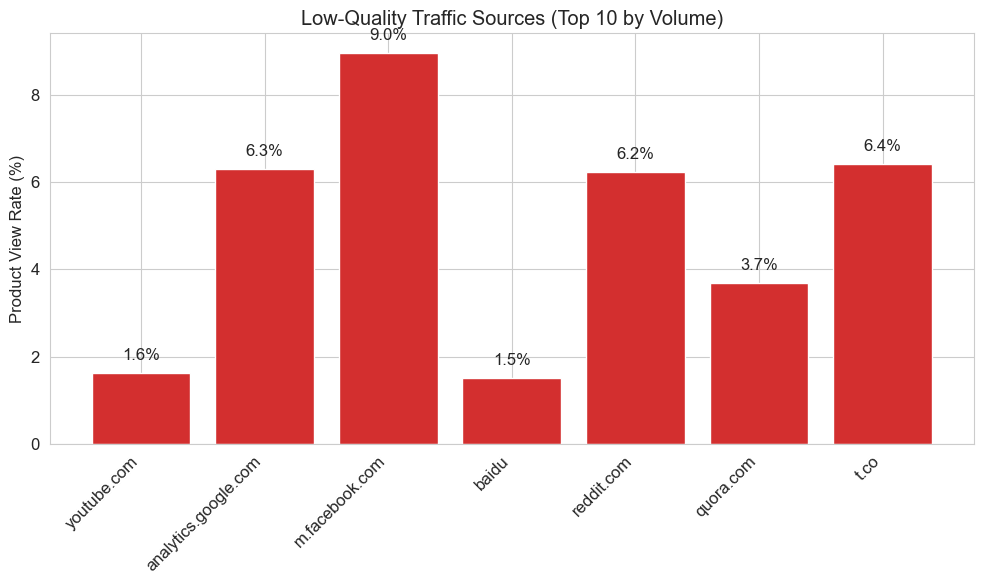

In [8]:
# 2. Source quality (top offenders)
df_traffic = pd.read_csv("data/traffic_quality.csv") 
df_traffic = df_traffic[df_traffic["sessions"] >= 1000].copy() # rename for clarity
low = df_traffic[df_traffic["traffic_quality"] == "low quality"].sort_values("sessions", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(low["source"], low["product_view_rate"], color="#d32f2f")
ax.set_ylabel("Product View Rate (%)")
ax.set_title("Low-Quality Traffic Sources (Top 10 by Volume)")
ax.set_xticklabels(low["source"], rotation=45, ha="right")
for bar, rate in zip(bars, low["product_view_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{rate:.1f}%", ha='center')
plt.tight_layout()
plt.savefig("visuals/source_quality_bar.png", dpi=150)
plt.show()

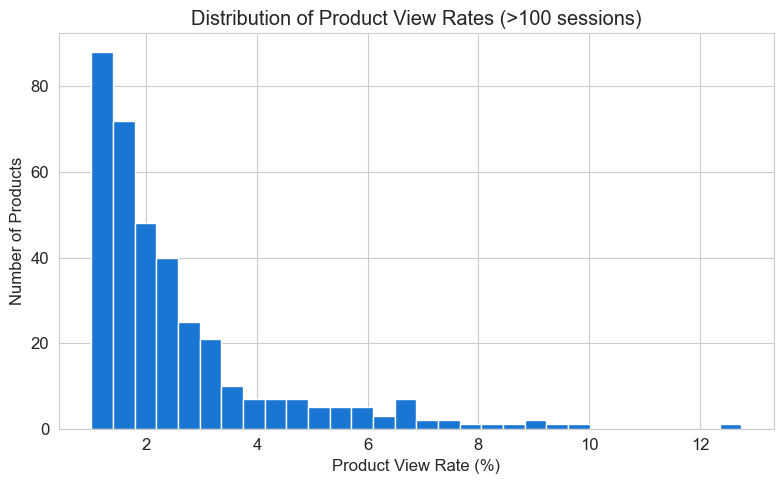

In [7]:
# 3. Product desirability distribution
df_prod = pd.read_csv("data/product_desirability.csv")
# Filter out the weird 90% dog frisbee and <100 session entries
df_prod_clean = df_prod[(df_prod["sessions"] >= 100) & (df_prod["product_view_rate"] < 50)]
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_prod_clean["product_view_rate"], bins=30, color="#1976d2", edgecolor="white")
ax.set_xlabel("Product View Rate (%)")
ax.set_ylabel("Number of Products")
ax.set_title("Distribution of Product View Rates (>100 sessions)")
plt.tight_layout()
plt.savefig("visuals/product_view_distribution.png", dpi=150)
plt.show()